In [8]:
import numpy as np
import matplotlib.pyplot as plt
from Utilities import extractor
import uproot
import awkward as ak    

x_MH175=extractor("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH175_LH_2017.root", "Events")



file=uproot.open("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH175_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
booleanas=tree.arrays(["FatJet_isMatchedWith2BHadrons"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]
Fatjet_isMatchedWith2BHadrons= booleanas["FatJet_isMatchedWith2BHadrons"]

#Filtriamo i dati

mask = (ak.flatten(Fatjet_isMatchedWithA) == 1) & (ak.flatten(Fatjet_isMatchedWith2BHadrons) == 1)
x_filtered = x_MH175[mask]


/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Nessuna cache trovata.
<ValueView norm=1.0059926985437169 mu=177.01833458495634 sigma=12.871432609541746 gamma=4.379951798539141>
chi2/ndof =  30.349566857527176


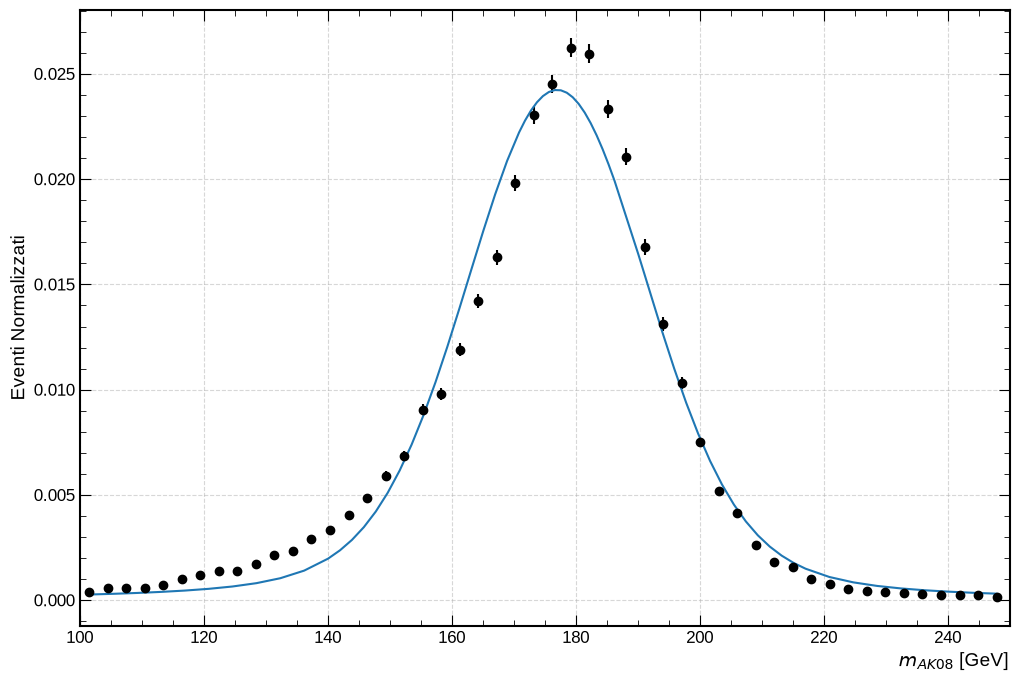

In [9]:
from scipy.special import voigt_profile
from iminuit import Minuit
from iminuit.cost import LeastSquares
from matplotlib.ticker import AutoMinorLocator

import matplotlib
import shutil
import os

# Ottieni il percorso della directory della cache
cache_dir = matplotlib.get_cachedir()

# Se la cartella esiste, eliminala
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cache eliminata con successo: {cache_dir}")
else:
    print("Nessuna cache trovata.")

x_plot=list(x_filtered)
x_plot.sort()
x_easy=[x for x in x_plot if 100 < x < 250]

def voigt(x, norm, mu, sigma, gamma):
    return voigt_profile(x-mu, sigma, gamma) * norm

bin_counts, bin_edges = np.histogram(x_easy, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_easy) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_easy) * bin_width) # Errore standard per i dati binned

ls_voigt=LeastSquares(bin_centers, bin_densities, yerr, model=voigt)

m_voigt=Minuit(ls_voigt,  norm=1, mu=175, sigma=5, gamma=2)
m_voigt.limits["mu"]= (150, 200)
m_voigt.limits["sigma"]= (0.1, 20)
m_voigt.limits["gamma"]= (0.01, 10)
m_voigt.migrad()

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})


fix, ax= plt.subplots(figsize=(12, 8))



m_voigt.visualize()
#plt.legend(loc= "upper right", fontsize=14, frameon=True, framealpha=0.9, title="Fit ottimizzato con Minuit")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(100, 250)
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Voigt_Minuit_175', bbox_inches='tight')
print(m_voigt.values)
print("chi2/ndof = ", m_voigt.fval / m_voigt.ndof)

In [10]:
fit_MH175_values={}
fit_MH175_errors={}

fit_values={'MH175': fit_MH175_values,}
fit_errors={'MH175_errors': fit_MH175_errors}

for param in m_voigt.parameters:
    fit_MH175_values[param] = m_voigt.values[param]

for error in m_voigt.parameters:    #Qui non ho capito come fa a capire che deveestarre gli errori 
    fit_MH175_errors[error] = m_voigt.errors[error]

print(fit_MH175_values)
print(fit_MH175_errors)

import json
#QUi sono andato di metodo oragutang, ho deciso di voler fare 2 file separati peer errori e valori 
#Ho tenuto lo stesso quello con tutti i valori, casomai cambiassi idea

with open("fit_results.json", "r") as f:
    results=json.load(f)

with open("fit_values.json", "r") as g:
    values=json.load(g) 

with open("fit_errors.json", "r") as h:
    errors=json.load(h)


results["MH175"]=fit_MH175_values
results["MH175_errors"]=fit_MH175_errors

with open("fit_results.json", "w") as f:
    json.dump(results, f, indent=1)

values["MH175"]=fit_MH175_values
with open("fit_values.json", "w") as g:
    json.dump(values, g, indent=1)  

errors["MH175_errors"]=fit_MH175_errors
with open("fit_errors.json", "w") as h:
    json.dump(errors, h, indent=1)  


{'norm': 1.0059926985437169, 'mu': 177.01833458495634, 'sigma': 12.871432609541746, 'gamma': 4.379951798539141}
{'norm': 0.005095247691029635, 'mu': 0.09181813101423586, 'sigma': 0.15028927532181502, 'gamma': 0.1307599677210214}


Nessuna cache trovata.


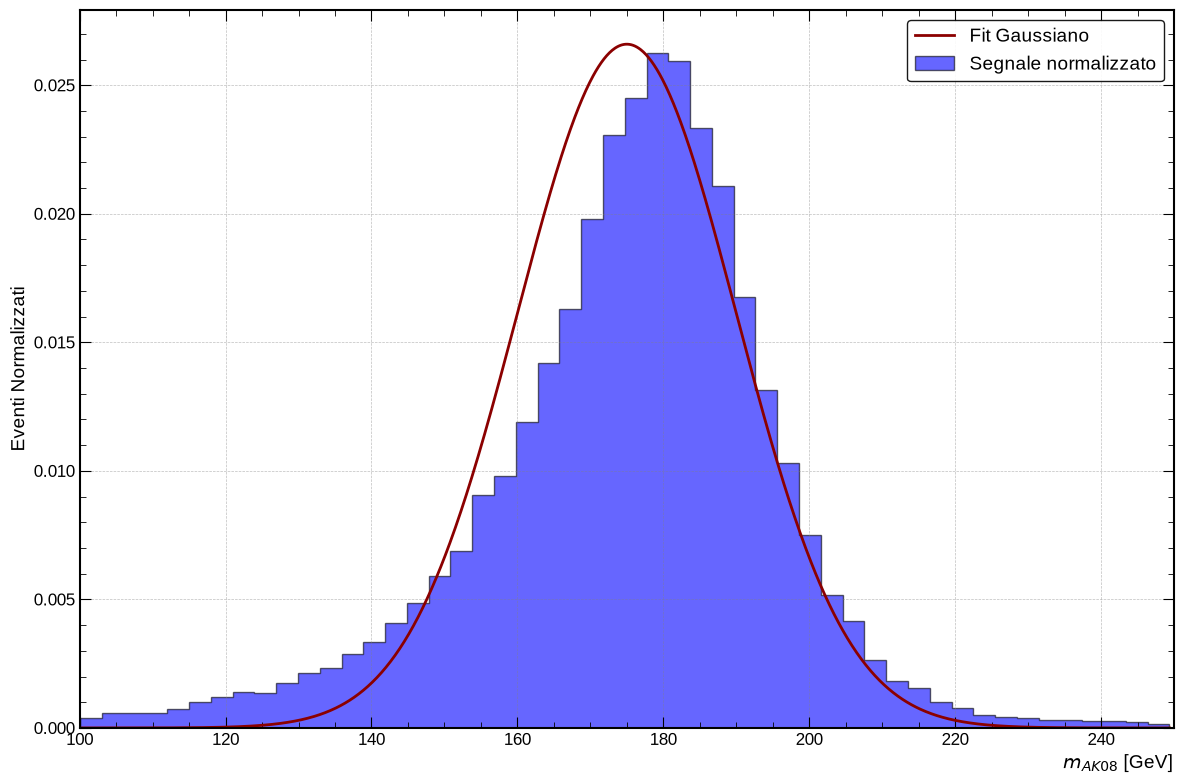

In [11]:
from numba_stats import truncnorm

import matplotlib
import shutil
import os

# Ottieni il percorso della directory della cache
cache_dir = matplotlib.get_cachedir()

# Se la cartella esiste, eliminala
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cache eliminata con successo: {cache_dir}")
else:
    print("Nessuna cache trovata.")

def gaussiana(x, mu, sigma):
    return truncnorm.pdf(x, *x_range, loc=mu, scale=sigma)

x_gauss=x_easy
x_range=(0, max(x_gauss))
y_gauss=gaussiana(x_gauss, mu=175, sigma=15)

fix, ax= plt.subplots(figsize=(12, 8))

plt.plot(x_gauss, y_gauss, color="darkred", alpha=1, linewidth=2, label="Fit Gaussiano")
ax.hist(x_gauss, bins=50, density=True, alpha=0.6, histtype="stepfilled", color="blue", edgecolor="black", label="Segnale normalizzato")
ax.set_xlim(100, 250)
ax.set_ylim(bottom=0)
plt.title("")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc="upper right", fontsize=14, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9)
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
#plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Gauss_175.png', bbox_inches='tight')
plt.show()

Nessuna cache trovata.
<ValueView mu=176.71494368102213 sigma=16.885372167492807>
chi2/ndof =  56.90474019863333


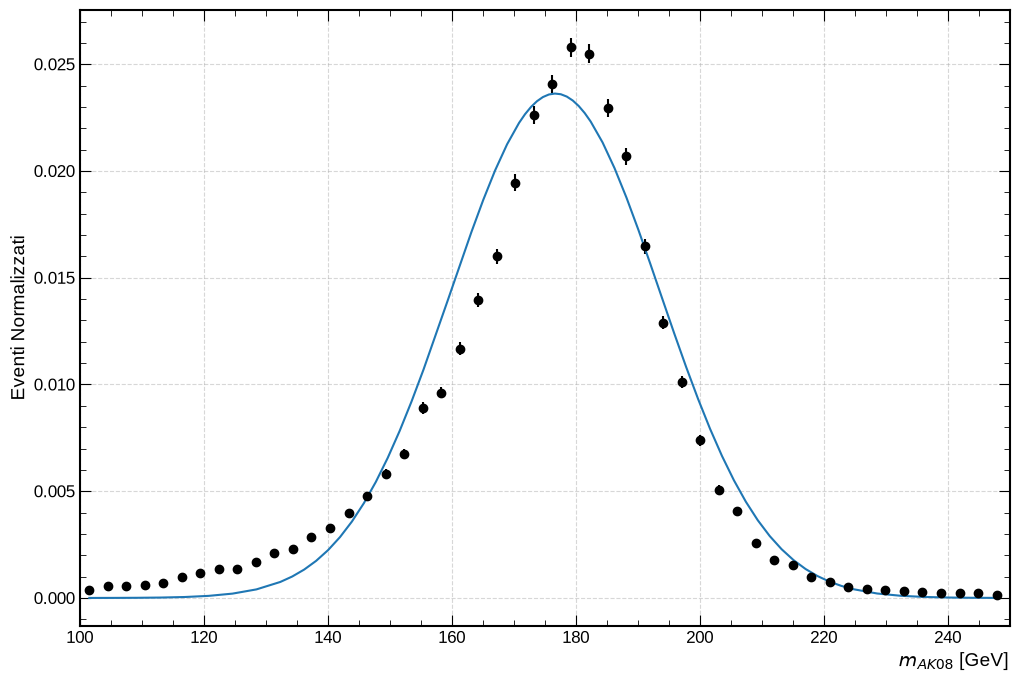

In [12]:
import matplotlib
import shutil
import os

# Ottieni il percorso della directory della cache
cache_dir = matplotlib.get_cachedir()

# Se la cartella esiste, eliminala
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cache eliminata con successo: {cache_dir}")
else:
    print("Nessuna cache trovata.")




bin_counts, bin_edges = np.histogram(x_easy, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_plot) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_plot) * bin_width) # Errore standard per i dati binned

ls_gauss=LeastSquares(bin_centers, bin_densities, yerr, model=gaussiana)
m_gauss=Minuit(ls_gauss, mu=175, sigma=15)
m_gauss.limits["mu"]= (150, 200)
m_gauss.limits["sigma"]= (0.1, 20)
m_gauss.migrad()

ix, ax= plt.subplots(figsize=(12, 8))



m_gauss.visualize()
#plt.legend(loc= "upper right", fontsize=14, frameon=True, framealpha=0.9, title="Fit ottimizzato con Minuit")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(100, 250)
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Gauss_Minuit_175', bbox_inches='tight')
print(m_gauss.values)
print("chi2/ndof = ", m_gauss.fval / m_gauss.ndof)

Nessuna cache trovata.


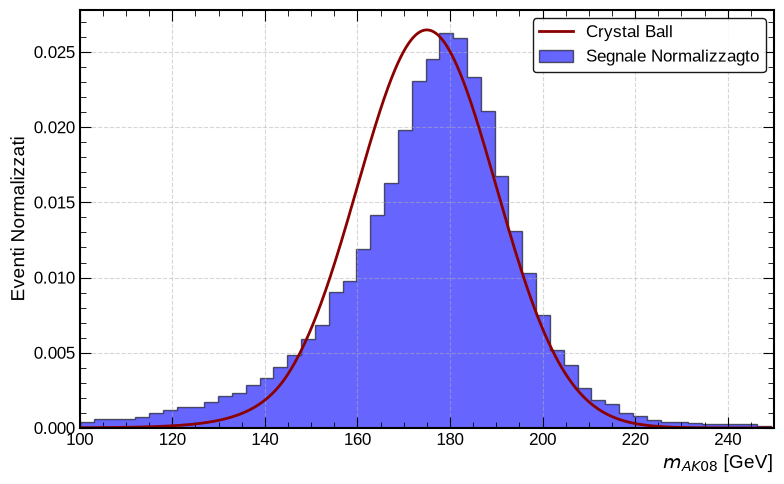

In [13]:
import matplotlib
import shutil
import os

# Ottieni il percorso della directory della cache
cache_dir = matplotlib.get_cachedir()

# Se la cartella esiste, eliminala
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cache eliminata con successo: {cache_dir}")
else:
    print("Nessuna cache trovata.")



from Utilities import cb_pdf

x_CB=x_easy
y_CB=[cb_pdf(xi, mu=175, sigma=15, beta=2, m=50 ) for xi in x_CB]

fig, ax = plt.subplots(figsize=(8, 5))
#plt.scatter(x_filtered, y_filtered, color="purple", alpha=0.8, label="Dati Filtrati")
plt.plot(x_CB, y_CB, color="darkred", alpha=1, linewidth=2, label="Crystal Ball")
ax.hist(x_CB, bins=50, density=True, alpha=0.6, color="blue", edgecolor='black',  histtype="stepfilled", label="Segnale Normalizzagto")
plt.title("")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim(bottom=0)
ax.set_xlim(100, 250)
ax.legend(loc='upper right', frameon=True, fontsize=12, framealpha=0.9, edgecolor='black')
plt.tight_layout()
#plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Crystall_Ball_50_GeV.png', bbox_inches='tight')
plt.show()  

Nessuna cache trovata.
<ValueView mu=179.0349961364664 sigma=14.33410738145899 beta=0.9274828666787828 m=12.625354355470208>
chi2/ndof =  10.88551752382522


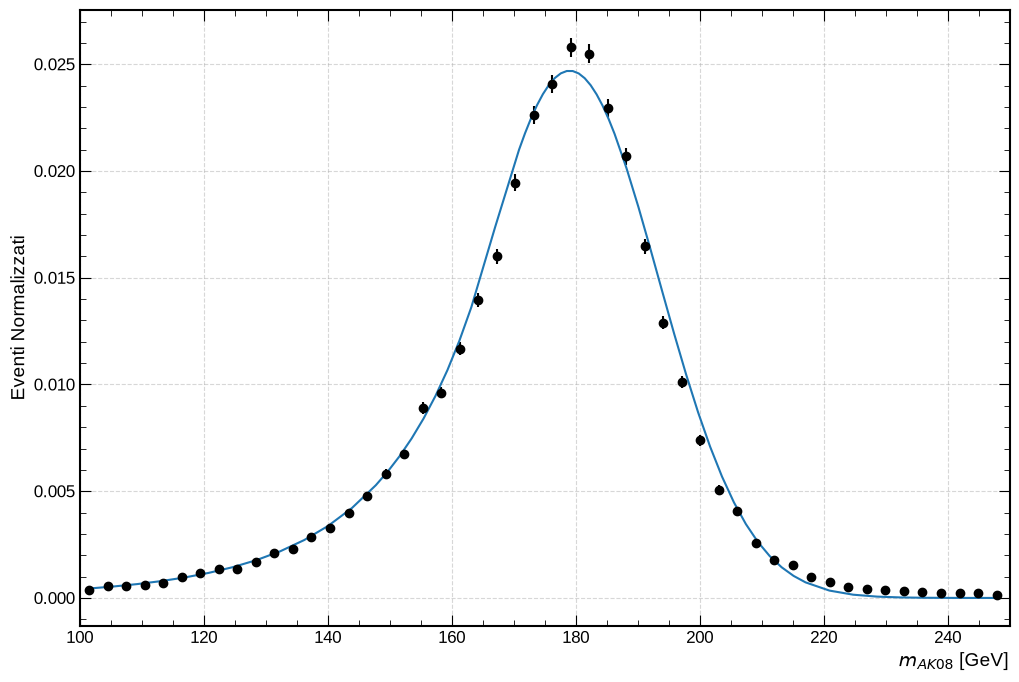

In [14]:
import matplotlib
import shutil
import os

# Ottieni il percorso della directory della cache
cache_dir = matplotlib.get_cachedir()

# Se la cartella esiste, eliminala
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cache eliminata con successo: {cache_dir}")
else:
    print("Nessuna cache trovata.")


ls_CB=LeastSquares(bin_centers, bin_densities, yerr, model=cb_pdf)
m=Minuit(ls_CB, mu=175, sigma=15, beta=0.5, m=30)
m.limits["mu"]= (150, 225)
m.limits["sigma"]= (0.1, 20)
m.limits["beta"]= (0.1, 10)
m.limits["m"]= (0.1, 100)
m.migrad()  



ix, ax= plt.subplots(figsize=(12, 8))

m.visualize()
#plt.legend(loc= "upper right", fontsize=14, frameon=True, framealpha=0.9, title="Fit ottimizzato con Minuit")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(100, 250)
ax.grid(True, linestyle='--', alpha=0.5)

plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/CrystallBall_Minuit_175', bbox_inches='tight')
print(m.values)
print("chi2/ndof = ", m.fval / m.ndof)